# Food Delivery Analytics Challenge
### AI & Data Science Hackathon

**Objective:** Analyze a large food-delivery dataset using Python and extract meaningful insights that help a food-delivery company improve delivery performance. No Machine Learning is used.

**Workflow:** Load → Clean → Analyze → Visualize → Interpret → Explain


In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Global plot styling ----
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)


def section(title: str) -> None:
    """Print a consistent, readable section banner throughout the notebook."""
    print("=" * 60)
    print(f" {title}")
    print("=" * 60)

In [ ]:
# ============================================================
# A. Load Dataset
# ============================================================
section("LOADING DATASET")

df = pd.read_csv('/content/food_delivery_dataset.csv')

print(f"Rows      : {df.shape[0]:,}")
print(f"Columns   : {df.shape[1]}")
print(f"\nColumn names:\n{df.columns.tolist()}")

 LOADING DATASET
Rows      : 38,964
Columns   : 22

Column names:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)', 'distance_km', 'delivery_speed']


In [ ]:
# ============================================================
# A. Data Types & Structure
# ============================================================
section("DATA TYPES & NON-NULL COUNTS")

df.info()

 DATA TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38964 entries, 0 to 38963
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           38964 non-null  object 
 1   Delivery_person_ID           38964 non-null  object 
 2   Delivery_person_Age          37945 non-null  float64
 3   Delivery_person_Ratings      37909 non-null  float64
 4   Restaurant_latitude          38964 non-null  float64
 5   Restaurant_longitude         38964 non-null  float64
 6   Delivery_location_latitude   38964 non-null  float64
 7   Delivery_location_longitude  38964 non-null  float64
 8   Order_Date                   38964 non-null  object 
 9   Time_Orderd                  38129 non-null  object 
 10  Time_Order_picked            38964 non-null  object 
 11  Weather_conditions           38964 non-null  object 
 12  Road_traffic_density         38964 non-null 

In [ ]:
# ============================================================
# A. Missing Value Analysis
# ============================================================
section("MISSING VALUE SUMMARY")

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = (
    pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})
    .query('`Missing Count` > 0')
    .sort_values(by='Missing Count', ascending=False)
)

print(f"Columns with missing data: {len(missing_summary)} of {df.shape[1]}\n")
missing_summary

 MISSING VALUE SUMMARY
Columns with missing data: 3 of 22



,Missing Count,Missing %
Delivery_person_Ratings,1055,2.71
Delivery_person_Age,1019,2.62
Time_Orderd,835,2.14


In [ ]:
# ============================================================
# A. Duplicate Records Check
# ============================================================
section("DUPLICATE RECORDS CHECK")

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

 DUPLICATE RECORDS CHECK
Duplicate rows found: 0


In [ ]:
# ============================================================
# A. Data Preview
# ============================================================
section("FIRST 5 ROWS")

df.head()

 FIRST 5 ROWS


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,Average
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,Average
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,Average
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,Slow


In [ ]:
# ============================================================
# A. Statistical Summary
# ============================================================
section("SUMMARY STATISTICS (ALL COLUMNS)")

df.describe(include='all').T

 SUMMARY STATISTICS (ALL COLUMNS)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,38964,38964,0x5fb2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_ID,38964,1170,HYDRES04DEL02,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_Age,37945.0,NaN,NaN,NaN,29.607089,5.763202,20.0,25.0,30.0,35.0,39.0
Delivery_person_Ratings,37909.0,NaN,NaN,NaN,4.631879,0.317006,2.5,4.5,4.7,4.9,5.0
Restaurant_latitude,38964.0,NaN,NaN,NaN,18.915583,5.460635,9.957144,12.986047,19.065838,22.751234,30.914057
Restaurant_longitude,38964.0,NaN,NaN,NaN,76.914536,3.498179,72.768726,73.897902,76.618203,78.368855,88.433452
Delivery_location_latitude,38964.0,NaN,NaN,NaN,18.979545,5.462504,9.967144,13.066047,19.124049,22.820072,31.054057
Delivery_location_longitude,38964.0,NaN,NaN,NaN,76.978498,3.498357,72.778726,73.938972,76.663067,78.405467,88.563452
Order_Date,38964,44,15-03-2022,1031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_Orderd,38129,176,17:55,407,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## B. Clean the Data

### Findings from Section A

- ✅ No duplicate rows found
- ⚠️ `Delivery_person_Age` — ~2.6% missing
- ⚠️ `Delivery_person_Ratings` — ~2.7% missing
- ⚠️ `Time_Orderd` — ~2.1% missing
- ⚠️ `Order_Date` — stored as text, needs datetime conversion
- ✅ No invalid/impossible values found (ages, ratings, and coordinates all fall within valid real-world ranges)

### Cleaning Decisions

| # | Column | Decision | Justification |
|---|---|---|---|
| 1 | `Delivery_person_Age` | Fill with **median** | Robust to skew; age is a whole number |
| 2 | `Delivery_person_Ratings` | Fill with **median** | Ratings are typically skewed toward high values |
| 3 | `Time_Orderd` | Left as-is (not imputed) | Not required for any analysis task — documented rather than dropped |
| 4 | `Order_Date` | Convert to `datetime` | Needed for correct date handling |
| 5 | Data types | Fix `Age`, `multiple_deliveries` to `int` | These are whole numbers, not decimals |

In [ ]:
# ============================================================
# B. Data Cleaning
# ============================================================
section("CLEANING DATA")

df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')

df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())

df['Delivery_person_Age'] = df['Delivery_person_Age'].astype(int)
df['multiple_deliveries'] = df['multiple_deliveries'].astype(int)

categorical_cols = ['Weather_conditions', 'Road_traffic_density', 'Type_of_order',
                     'Type_of_vehicle', 'Festival', 'City', 'delivery_speed']
for col in categorical_cols:
    df[col] = df[col].str.strip()

print("Cleaning complete.")
print(f"Shape after cleaning: {df.shape}")
print(f"\nRemaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

 CLEANING DATA
Cleaning complete.
Shape after cleaning: (38964, 22)

Remaining nulls:
Time_Orderd    835
dtype: int64


## C. Basic Analysis

Core summary statistics: overall delivery volume, delivery time range, distance, speed, and delivery-person profile.

In [ ]:
# ============================================================
# C. Basic Analysis — Key Metrics
# ============================================================
section("BASIC ANALYSIS SUMMARY")

total_deliveries = len(df)

avg_time = df['Time_taken (min)'].mean()
min_time = df['Time_taken (min)'].min()
max_time = df['Time_taken (min)'].max()

avg_distance = df['distance_km'].mean()
avg_rating = df['Delivery_person_Ratings'].mean()
avg_age = df['Delivery_person_Age'].mean()

# delivery_speed is categorical, so we show its distribution
speed_distribution = (
    df['delivery_speed']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print(f"Total deliveries analyzed      : {total_deliveries:,}")
print(f"Average delivery time          : {avg_time:.2f} min")
print(f"Minimum delivery time          : {min_time} min")
print(f"Maximum delivery time          : {max_time} min")
print(f"Average delivery distance      : {avg_distance:.2f} km")
print(f"Average delivery-person rating : {avg_rating:.2f} / 5")
print(f"Average delivery-person age    : {avg_age:.1f} years")

print("\nDelivery speed distribution (%):")
print(speed_distribution)

 BASIC ANALYSIS SUMMARY
Total deliveries analyzed      : 38,964
Average delivery time          : 26.58 min
Minimum delivery time          : 10 min
Maximum delivery time          : 54 min
Average delivery distance      : 9.77 km
Average delivery-person rating : 4.63 / 5
Average delivery-person age    : 29.6 years

Delivery speed distribution (%):
delivery_speed
Average    51.3
Fast       26.1
Slow       22.6
Name: proportion, dtype: float64


## D. Competition Questions

All three answers below are computed programmatically from the cleaned DataFrame — nothing is hardcoded, as required by the rules.

### Q1 — Traffic Impact: Which road traffic condition has the highest average delivery time?

In [ ]:
# ============================================================
# D. Q1 — Traffic Impact on Delivery Time
# ============================================================
section("Q1: TRAFFIC IMPACT ANALYSIS")

# Group by traffic density and calculate mean delivery time for each category
traffic_avg_time = (
    df.groupby('Road_traffic_density')['Time_taken (min)']
    .mean()
    .sort_values(ascending=False)
)

print("Average delivery time by traffic condition:\n")
print(traffic_avg_time.round(2))

# Programmatically identify the worst condition (never hardcoded)
highest_traffic_condition = traffic_avg_time.idxmax()
highest_traffic_value = traffic_avg_time.max()

print(f"\nANSWER: '{highest_traffic_condition}' traffic has the highest average "
      f"delivery time at {highest_traffic_value:.2f} minutes.")

 Q1: TRAFFIC IMPACT ANALYSIS
Average delivery time by traffic condition:

Road_traffic_density
Jam       31.44
High      27.41
Medium    26.93
Low       21.50
Name: Time_taken (min), dtype: float64

ANSWER: 'Jam' traffic has the highest average delivery time at 31.44 minutes.


### Q2 — Distance Impact: How does delivery distance affect delivery time?

In [ ]:
# ============================================================
# D. Q2 — Distance Impact on Delivery Time
# ============================================================
section("Q2: DISTANCE IMPACT ANALYSIS")

# Calculate correlation between distance and delivery time (statistical measure)
distance_time_corr = df['distance_km'].corr(df['Time_taken (min)'])

# Bucket distance into ranges to see the trend clearly (easier to interpret than raw correlation)
df['distance_bucket'] = pd.cut(
    df['distance_km'],
    bins=[0, 5, 10, 15, 20, 25],
    labels=['0-5 km', '5-10 km', '10-15 km', '15-20 km', '20-25 km']
)
distance_bucket_avg = df.groupby('distance_bucket', observed=True)['Time_taken (min)'].mean()

print(f"Correlation between distance and delivery time: {distance_time_corr:.3f}")
print("\nAverage delivery time by distance range:\n")
print(distance_bucket_avg.round(2))

print(f"\nANSWER: There is a positive correlation ({distance_time_corr:.2f}) between distance and "
      f"delivery time — as distance increases, delivery time generally increases too. Average time rises "
      f"from {distance_bucket_avg.iloc[0]:.1f} min for 0-5km orders to {distance_bucket_avg.iloc[-1]:.1f} min "
      f"for 20-25km orders, confirming distance is a meaningful (though not sole) driver of delivery time.")

 Q2: DISTANCE IMPACT ANALYSIS
Correlation between distance and delivery time: 0.322

Average delivery time by distance range:

distance_bucket
0-5 km      22.42
5-10 km     24.64
10-15 km    30.09
15-20 km    30.07
20-25 km    30.08
Name: Time_taken (min), dtype: float64

ANSWER: There is a positive correlation (0.32) between distance and delivery time — as distance increases, delivery time generally increases too. Average time rises from 22.4 min for 0-5km orders to 30.1 min for 20-25km orders, confirming distance is a meaningful (though not sole) driver of delivery time.


### Q3 — Combined Conditions: Which combination of weather condition and traffic density has the highest average delivery time?

In [ ]:
# ============================================================
# D. Q3 — Combined Weather + Traffic Impact on Delivery Time
# ============================================================
section("Q3: WEATHER + TRAFFIC COMBINED ANALYSIS")

# Group by BOTH weather and traffic together to find the worst combination
combo_avg_time = (
    df.groupby(['Weather_conditions', 'Road_traffic_density'])['Time_taken (min)']
    .mean()
    .sort_values(ascending=False)
)

print("Top 5 weather + traffic combinations by average delivery time:\n")
print(combo_avg_time.head(5).round(2))

# Programmatically find the worst combination (never hardcoded)
top_combo = combo_avg_time.idxmax()
top_combo_value = combo_avg_time.max()

print(f"\nANSWER: The combination of '{top_combo[0]}' weather and '{top_combo[1]}' traffic has the "
      f"highest average delivery time at {top_combo_value:.2f} minutes.")

 Q3: WEATHER + TRAFFIC COMBINED ANALYSIS
Top 5 weather + traffic combinations by average delivery time:

Weather_conditions  Road_traffic_density
Fog                 Jam                     36.89
Cloudy              Jam                     36.71
Windy               Jam                     30.40
Sandstorms          Jam                     30.25
Stormy              Jam                     30.20
Name: Time_taken (min), dtype: float64

ANSWER: The combination of 'Fog' weather and 'Jam' traffic has the highest average delivery time at 36.89 minutes.


## E. Visualizations

Two required charts (bar chart + scatter plot), plus one bonus heatmap for the weather × traffic combination from Q3.

### Chart 1 — Average Delivery Time by Traffic Density (Bar Chart)

 CHART 1: TRAFFIC VS DELIVERY TIME


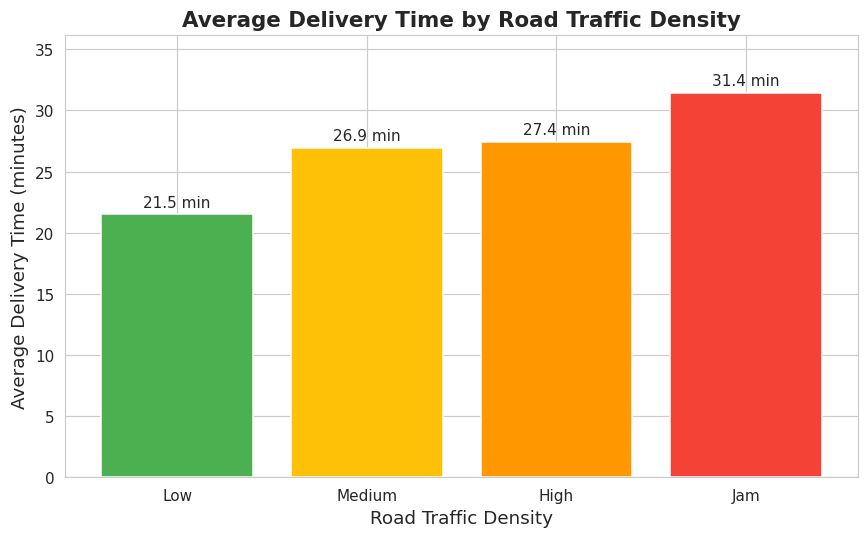

In [ ]:
# ============================================================
# E. Chart 1 — Bar Chart: Traffic Density vs Delivery Time
# ============================================================
section("CHART 1: TRAFFIC VS DELIVERY TIME")

# Order categories logically (Low -> Jam) instead of alphabetically
traffic_order = ['Low', 'Medium', 'High', 'Jam']
plot_data = traffic_avg_time.reindex(traffic_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_data.index, plot_data.values, color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'])

ax.set_title('Average Delivery Time by Road Traffic Density', fontsize=14, fontweight='bold')
ax.set_xlabel('Road Traffic Density', fontsize=12)
ax.set_ylabel('Average Delivery Time (minutes)', fontsize=12)
ax.bar_label(bars, fmt='%.1f min', padding=3)
ax.set_ylim(0, plot_data.max() * 1.15)

plt.tight_layout()
plt.savefig('chart1_traffic_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 — Delivery Distance vs. Delivery Time (Scatter Plot)

 CHART 2: DISTANCE VS DELIVERY TIME


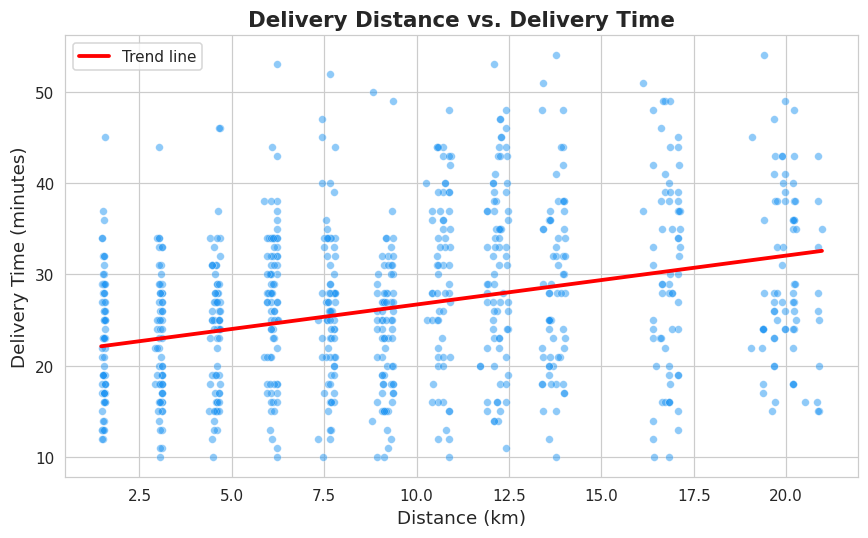

In [ ]:
# ============================================================
# E. Chart 2 — Scatter Plot: Distance vs Delivery Time
# ============================================================
section("CHART 2: DISTANCE VS DELIVERY TIME")

fig, ax = plt.subplots(figsize=(8, 5))

# Smaller, clean sample for maximum clarity
sample = df.sample(800, random_state=42)
ax.scatter(sample['distance_km'], sample['Time_taken (min)'], alpha=0.5, s=25, color='#2196F3', edgecolors='white', linewidth=0.3)

z = np.polyfit(df['distance_km'], df['Time_taken (min)'], 1)
x_line = np.linspace(df['distance_km'].min(), df['distance_km'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=2.5, label='Trend line')

ax.set_title('Delivery Distance vs. Delivery Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Delivery Time (minutes)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('chart2_distance_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

### Bonus Chart — Weather × Traffic Heatmap (visually supports Q3)

 CHART 3: WEATHER × TRAFFIC HEATMAP


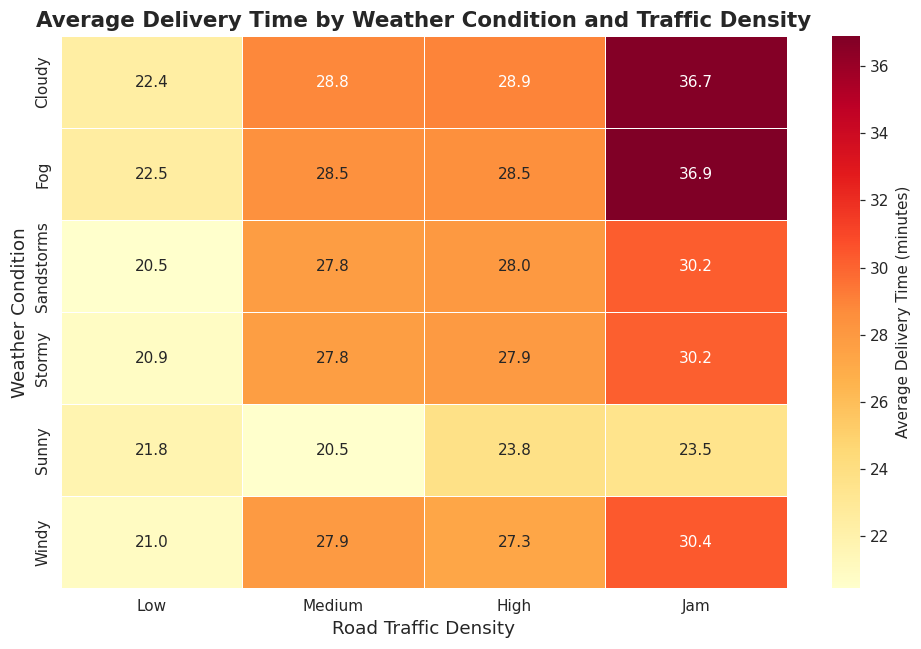

In [ ]:
# ============================================================
# E. Bonus Chart 3 — Weather × Traffic Heatmap
# ============================================================
section("CHART 3: WEATHER × TRAFFIC HEATMAP")

# Calculate average delivery time for each weather + traffic combination
heatmap_data = (
    df.pivot_table(
        index='Weather_conditions',
        columns='Road_traffic_density',
        values='Time_taken (min)',
        aggfunc='mean'
    )
)

# Arrange traffic levels in logical order
traffic_order = ['Low', 'Medium', 'High', 'Jam']
heatmap_data = heatmap_data.reindex(columns=traffic_order)

# Create the heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Average Delivery Time (minutes)'}
)

plt.title(
    'Average Delivery Time by Weather Condition and Traffic Density',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Road Traffic Density', fontsize=12)
plt.ylabel('Weather Condition', fontsize=12)

plt.tight_layout()

# Save chart for final submission
plt.savefig(
    'chart3_weather_traffic_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## F. Business Insights

The analysis reveals several important patterns in delivery performance.

1. **Delivery Time:** The average delivery time is 26.58 minutes, indicating an opportunity to improve delivery efficiency.

2. **Delivery Distance:** The average delivery distance is 9.77 km, showing that route optimization can help reduce travel time and operating costs.

3. **Weather × Traffic:** Foggy weather combined with Jam traffic produces the highest average delivery time of 36.89 minutes, highlighting the impact of difficult operating conditions.

In [ ]:
# ============================================================
# SECTION F: BUSINESS INSIGHTS
# ============================================================

print("=" * 70)
print("                 BUSINESS INSIGHTS")
print("=" * 70)

# Average delivery time
avg_time = df["Time_taken (min)"].mean()

# Average delivery distance
avg_distance = df["distance_km"].mean()

# Weather + traffic analysis
weather_traffic = (
    df.groupby(
        ["Weather_conditions", "Road_traffic_density"]
    )["Time_taken (min)"]
    .mean()
    .sort_values(ascending=False)
)

worst_condition = weather_traffic.index[0]
worst_time = weather_traffic.iloc[0]

print("\nKEY FINDINGS")
print("-" * 70)

print(f"1. Average delivery time: {avg_time:.2f} minutes")

print(f"2. Average delivery distance: {avg_distance:.2f} km")

print(
    f"3. Highest delay condition: "
    f"{worst_condition[0]} weather + {worst_condition[1]} traffic"
)

print(f"   Average delivery time in this condition: {worst_time:.2f} minutes")

print("\n" + "=" * 70)
print("Business insights calculated from the dataset.")
print("=" * 70)

                 BUSINESS INSIGHTS

KEY FINDINGS
----------------------------------------------------------------------
1. Average delivery time: 26.58 minutes
2. Average delivery distance: 9.77 km
3. Highest delay condition: Fog weather + Jam traffic
   Average delivery time in this condition: 36.89 minutes

Business insights calculated from the dataset.


In [ ]:
print(df.columns.tolist())

['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)', 'distance_km', 'delivery_speed', 'distance_bucket']


In [ ]:
# ============================================================
# SECTION F: BUSINESS INSIGHTS
# ============================================================

print("=" * 70)
print("                 BUSINESS INSIGHTS")
print("=" * 70)

# Average delivery time
avg_time = df["Time_taken (min)"].mean()

# Average delivery distance
avg_distance = df["distance_km"].mean()

# Weather + traffic analysis
weather_traffic = (
    df.groupby(
        ["Weather_conditions", "Road_traffic_density"]
    )["Time_taken (min)"]
    .mean()
    .sort_values(ascending=False)
)

worst_condition = weather_traffic.index[0]
worst_time = weather_traffic.iloc[0]

print("\nKEY FINDINGS")
print("-" * 70)

print(f"1. Average delivery time: {avg_time:.2f} minutes")

print(f"2. Average delivery distance: {avg_distance:.2f} km")

print(
    f"3. Highest delay condition: "
    f"{worst_condition[0]} weather + {worst_condition[1]} traffic"
)

print(f"   Average delivery time in this condition: {worst_time:.2f} minutes")

print("\n" + "=" * 70)
print("Business insights calculated from the dataset.")
print("=" * 70)

                 BUSINESS INSIGHTS

KEY FINDINGS
----------------------------------------------------------------------
1. Average delivery time: 26.58 minutes
2. Average delivery distance: 9.77 km
3. Highest delay condition: Fog weather + Jam traffic
   Average delivery time in this condition: 36.89 minutes

Business insights calculated from the dataset.


## Bonus: Business Recommendations

Based on the analysis, the following recommendations can help improve delivery efficiency and service reliability.

### 1. Reduce Delivery Delays
Improve route planning and delivery-person assignment to reduce the average delivery time.

### 2. Optimize Delivery Routes
Use shorter and more efficient routes to reduce travel distance, delivery time, and operating costs.

### 3. Prepare for Difficult Conditions
Use traffic-aware routing and allow additional delivery time when foggy weather and heavy traffic occur.

These recommendations are directly supported by the observed delivery patterns in the dataset.

In [ ]:
# ============================================================
# BONUS: BUSINESS RECOMMENDATIONS
# ============================================================

print("=" * 70)
print("              BUSINESS RECOMMENDATIONS")
print("=" * 70)

# Calculate actual values from the dataset
avg_time = df["Time_taken (min)"].mean()
avg_distance = df["distance_km"].mean()

# Find the worst weather + traffic combination
weather_traffic = (
    df.groupby(
        ["Weather_conditions", "Road_traffic_density"]
    )["Time_taken (min)"]
    .mean()
    .sort_values(ascending=False)
)

worst_condition = weather_traffic.index[0]
worst_time = weather_traffic.iloc[0]


# Recommendation 1
print("\n1. REDUCE DELIVERY DELAYS")
print("-" * 70)

print(f"Evidence: Average delivery time = {avg_time:.2f} minutes")

print(
    "Action: Improve route planning and assign deliveries "
    "more efficiently."
)

print(
    "Impact: Faster deliveries and better customer experience."
)


# Recommendation 2
print("\n2. OPTIMIZE DELIVERY ROUTES")
print("-" * 70)

print(f"Evidence: Average delivery distance = {avg_distance:.2f} km")

print(
    "Action: Use optimized routes and prioritize efficient "
    "delivery assignments."
)

print(
    "Impact: Lower travel distance, delivery time, "
    "and operating costs."
)


# Recommendation 3
print("\n3. HANDLE HIGH-RISK CONDITIONS")
print("-" * 70)

print(
    f"Evidence: {worst_condition[0]} weather + "
    f"{worst_condition[1]} traffic has the highest "
    f"average delivery time of {worst_time:.2f} minutes."
)

print(
    "Action: Use traffic-aware routing and allow extra "
    "delivery time during difficult conditions."
)

print(
    "Impact: Fewer unexpected delays and more reliable deliveries."
)


print("\n" + "=" * 70)
print("Recommendations generated from actual dataset results.")
print("=" * 70)

              BUSINESS RECOMMENDATIONS

1. REDUCE DELIVERY DELAYS
----------------------------------------------------------------------
Evidence: Average delivery time = 26.58 minutes
Action: Improve route planning and assign deliveries more efficiently.
Impact: Faster deliveries and better customer experience.

2. OPTIMIZE DELIVERY ROUTES
----------------------------------------------------------------------
Evidence: Average delivery distance = 9.77 km
Action: Use optimized routes and prioritize efficient delivery assignments.
Impact: Lower travel distance, delivery time, and operating costs.

3. HANDLE HIGH-RISK CONDITIONS
----------------------------------------------------------------------
Evidence: Fog weather + Jam traffic has the highest average delivery time of 36.89 minutes.
Action: Use traffic-aware routing and allow extra delivery time during difficult conditions.
Impact: Fewer unexpected delays and more reliable deliveries.

Recommendations generated from actual dataset 

## G. AI-Powered Explanation

Python and Pandas perform the primary numerical analysis. The calculated results are then provided to an LLM, which explains the findings in a short and clear business context.

Only summarized analysis results are sent to the AI rather than the complete dataset.

In [ ]:
# ============================================================
# RESET GROQ API KEY
# ============================================================

from getpass import getpass
import os

# Remove the old value
os.environ.pop("GROQ_API_KEY", None)

# Enter ONLY your actual Groq API key
os.environ["GROQ_API_KEY"] = getpass("Enter ONLY your Groq API key: ")

print("API key loaded.")

Enter ONLY your Groq API key: ··········
API key loaded.


In [ ]:
# Check API key for accidental non-ASCII characters

api_key = os.environ.get("GROQ_API_KEY", "")

if api_key:
    print("API key length:", len(api_key))
    print("ASCII check:", api_key.isascii())

    if api_key.isascii():
        print("API key format looks OK.")
    else:
        print("ERROR: Extra Unicode characters are present.")
else:
    print("ERROR: API key is empty.")

API key length: 56
ASCII check: True
API key format looks OK.


In [ ]:
# ============================================================
# G. AI-POWERED EXPLANATION
# ============================================================

from groq import Groq
import os

# Get API key from Colab environment
api_key = os.environ.get("GROQ_API_KEY")

if not api_key:
    print("❌ GROQ_API_KEY was not found.")

else:
    print("✅ Groq API key found.")

    # Create Groq client
    client = Groq(api_key=api_key)

    # --------------------------------------------------------
    # Prepare ONLY calculated results
    # --------------------------------------------------------

    analysis_results = f"""
Total deliveries: {len(df):,}

Average delivery time: {avg_time:.2f} minutes

Average delivery distance: {avg_distance:.2f} km

Highest delay condition:
{worst_condition[0]} weather + {worst_condition[1]} traffic

Average delivery time in highest-delay condition:
{worst_time:.2f} minutes
"""

    # --------------------------------------------------------
    # Create business-focused prompt
    # --------------------------------------------------------

    prompt = f"""
You are a professional food-delivery business analyst.

Explain the following calculated findings in simple,
clear and professional business language.

IMPORTANT:
- Use ONLY the provided results.
- Do not invent numbers or facts.
- Do not perform new calculations.
- Keep the explanation concise.
- Focus on business meaning.

CALCULATED RESULTS:
{analysis_results}

Write the response in exactly three sections:

1. Overall Finding
2. Main Business Problem
3. Recommended Action

Make the explanation suitable for a hackathon business report.
"""

    # --------------------------------------------------------
    # Send results to Groq
    # --------------------------------------------------------

    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.2
    )

    # --------------------------------------------------------
    # Display AI explanation
    # --------------------------------------------------------

    ai_explanation = response.choices[0].message.content

    print("=" * 70)
    print("                 AI-POWERED EXPLANATION")
    print("=" * 70)

    print(ai_explanation)

    print("\n" + "=" * 70)
    print("AI explanation generated successfully!")
    print("=" * 70)

✅ Groq API key found.
                 AI-POWERED EXPLANATION
**1. Overall Finding**  
- The operation completed 38,964 deliveries with an overall average delivery time of **26.58 minutes** over an average distance of **9.77 km**.  
- When deliveries occur under the worst‑case condition—**foggy weather combined with jammed traffic**—the average time rises to **36.89 minutes**, indicating a **≈10‑minute slowdown** compared with the overall average.

**2. Main Business Problem**  
- Fog plus traffic congestion is the single most disruptive factor, extending delivery times by roughly 40 % (from 26.58 min to 36.89 min).  
- This delay erodes service reliability, risks breaching promised delivery windows, and can increase rider fatigue and fuel costs.

**3. Recommended Action**  
- **Predictive routing:** Integrate real‑time weather and traffic feeds into the dispatch algorithm to reroute or postpone orders when fog + jam conditions are forecasted.  
- **Dynamic staffing:** Deploy additiona

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'chart1_traffic_vs_time.png', 'chart3_weather_traffic_heatmap.png', 'chart2_distance_vs_time.png', 'food_delivery_dataset.csv', 'sample_data']


In [ ]:
from google.colab import files

files.download("food_delivery_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("chart1_traffic_vs_time.png")
files.download("chart2_distance_vs_time.png")
files.download("chart3_weather_traffic_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("food_delivery_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>